# Gaze model

This notebook contains the code for training and evaluating the gaze model.

In [1]:
import pickle
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import torch

from modeling import reading_measures
from modeling.dataset import GazeTextDataset
from modeling.gaze_models import CausalTransformerGazeModel, LinearRegressionGazeModel

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"

## Downloading and preprocessing the dataset

In [2]:
! emtec/get_emtec.sh

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   367  100   367    0     0   1308      0 --:--:-- --:--:-- --:--:--  1310
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0
100 34.5M  100 34.5M    0     0  12.4M      0  0:00:02  0:00:02 --:--:--  108M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   367  100   367    0     0   1272      0 --:--:-- --:--:-- --:--:--  1274
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0
100 9383k  100 9383k    0     0  3673k      0  0:00:02  0:00:02 --:--:-- 3673k


In [3]:
reading_measure = reading_measures.first_pass_gaze_duration
outlier_zscore = 3

# Load dataset
emtec = GazeTextDataset.load(
    "emtec/fixations",
    reading_measure,
    outlier_zscore,
)

# Split dataset
train_dataset, dev_dataset = emtec.random_split(0.8)
print(f"Train: {len(train_dataset.texts)} texts, {len(train_dataset.gaze_data)} AOIs")
print(f"Dev: {len(dev_dataset.texts)} texts, {len(dev_dataset.gaze_data)} AOIs")

# Normalize reading measures based on training set
train_dataset.normalize_gaze_labels()
dev_dataset.normalize_gaze_labels(
    train_dataset.gaze_label_mean, train_dataset.gaze_label_std
)

Train: 470 texts, 40356 AOIs
Dev: 118 texts, 9518 AOIs


## Training the model

In [ ]:
trf_gaze_model = CausalTransformerGazeModel.from_pretrained(
    "openai-community/gpt2"
).to(device)
trf_gaze_model.fit(
    train_dataset,
    dev_dataset,
    batch_size=10,
    patience=3,
    learning_rate=0.0001,
)

# Save the trained model
torch.save(trf_gaze_model.state_dict(), "models/trf_gaze_model.pt")

### Alternative: Loading the trained model

In [4]:
trf_gaze_model = CausalTransformerGazeModel.from_pretrained(
    "openai-community/gpt2"
).to(device)
trf_gaze_model.load_state_dict(torch.load("models/trf_gaze_model.pt", map_location=device))

<All keys matched successfully>

## Training the linear regression baseline

In [5]:
lr_gaze_model = LinearRegressionGazeModel(lang="en", max_spillover=2)
lr_gaze_model.fit(
    train_dataset,
    dev_dataset,
)

# Save the trained model
with open("models/lr_gaze_model.pkl", "wb") as f:
    pickle.dump(lr_gaze_model, f)

## Evaluating the models

Text(0, 0.5, 'Observed')

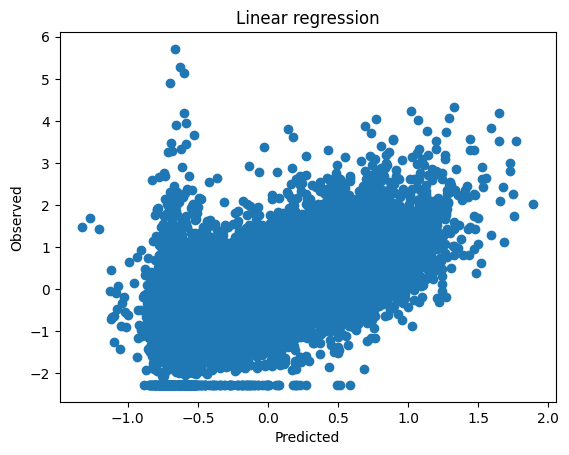

In [6]:
lr_results = lr_gaze_model.evaluate(dev_dataset)
plt.scatter(lr_results["preds"], lr_results["labels"])
plt.title("Linear regression")
plt.xlabel("Predicted")
plt.ylabel("Observed")

Text(0, 0.5, 'Observed')

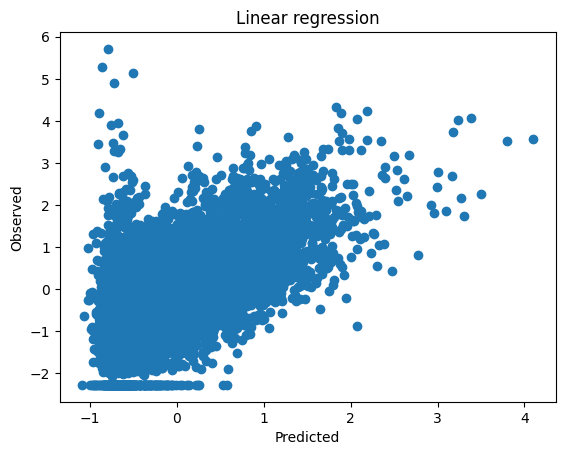

In [7]:
trf_results = trf_gaze_model.evaluate(dev_dataset)
plt.scatter(trf_results["preds"], trf_results["labels"])
plt.title("Linear regression")
plt.xlabel("Predicted")
plt.ylabel("Observed")

In [8]:
pd.DataFrame(
    {
        metric: [
            lr_results[metric],
            trf_results[metric],
        ]
        for metric in ["mse", "rmse", "mae", "r2"]
    },
    index=["Linear regression", "Transformer"]
)

,mse,rmse,mae,r2
Linear regression,0.670718,0.818974,0.615190,0.314421
Transformer,0.630666,0.794145,0.596862,0.355360
